In [34]:
import pandas as pd
import numpy as np

In [35]:
df = pd.read_csv('data/weather/weather_ny_2014_2019.csv', usecols=['DATE', 'TMAX', 'TMIN'])
df['tavg'] = (df.TMAX + df.TMIN)/2
print(df.shape)
print(df.dtypes)
print(df.columns)
print(df.isnull().sum())
display(df.head(3))

(2191, 4)
DATE     object
TMAX    float64
TMIN    float64
tavg    float64
dtype: object
Index(['DATE', 'TMAX', 'TMIN', 'tavg'], dtype='object')
DATE    0
TMAX    0
TMIN    0
tavg    0
dtype: int64


,DATE,TMAX,TMIN,tavg
0,2014-01-01,0.6,-4.3,-1.85
1,2014-01-02,0.6,-7.7,-3.55
2,2014-01-03,-7.7,-12.7,-10.20


In [36]:
df['DATE'] = pd.to_datetime(df['DATE'])
#print(df.dtypes)
#display(df.head(3))

df_week = df.resample('W', on='DATE').agg(func = None, 
    temp_avg = pd.NamedAgg(column='tavg', aggfunc='mean'))

print(df_week.shape)
display(df_week.head(5))

(314, 1)


,temp_avg
DATE,
2014-01-05,-4.430000
2014-01-12,-0.435714
2014-01-19,4.350000
2014-01-26,-5.950000
2014-02-02,-1.014286


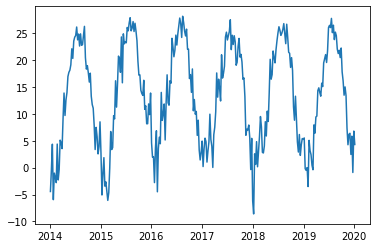

In [37]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df_week.index, df_week.temp_avg)
plt.show()

In [38]:
df_week.to_parquet('all_weather_weekly.parquet')

In [39]:
import gc
del df
del df_week
gc.collect()

6567

In [41]:
df = pd.read_parquet('all_weather_weekly.parquet')
print(df.shape)

(314, 1)


In [42]:
display(df.head(3))

,temp_avg
DATE,
2014-01-05,-4.430000
2014-01-12,-0.435714
2014-01-19,4.350000
